<a href="https://colab.research.google.com/github/EmmanuelC-137/Mineria_de_datos/blob/main/Proyecto_mineria.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#Proyecto de Mineria de datos

# Proyecto Minería de Datos: Reconocimiento de Voz "Luz Inteligente"

**Integrantes:**
- Martin Eduardo Zúñiga Martinez
- Juan Antonio Cabrera Meza
- Emmanuel Hernández Méndez

**Grupo(s):** [6:00–7:00 PM / 8:00–9:00 PM]

**Fecha de entrega:** 25 de mayo de 2026

---

## Índice
1. [Fase 1: Preparación de la Libreta Colab](#fase1)
2. [Fase 2: Adquisición y Procesamiento de Datos](#fase2)
3. [Fase 3: Desarrollo del Modelo y Optimización](#fase3)
4. [Fase 4: Evaluación y Resultados](#fase4)
5. [Conclusiones](#conclusiones)

---

## Introducción Teórica

### Procesamiento de audio
El procesamiento de audio implica la manipulación y análisis de señales acústicas. En el contexto del aprendizaje automático, el audio crudo (una secuencia de amplitudes en el tiempo) es difícil de procesar directamente debido a su alta dimensionalidad y variabilidad. Por ello, se recurre a técnicas de extracción de características.

### Uso de MFCC (Coeficientes Cepstrales en Frecuencia Mel)
Los MFCC son representaciones de características ampliamente utilizadas en el procesamiento del habla. Se basan en la percepción humana del sonido, utilizando la escala Mel, que aproxima la respuesta no lineal del oído humano a diferentes frecuencias. Los MFCC capturan la envolvente espectral de un sonido, lo cual es fundamental para distinguir diferentes fonemas y palabras.

### Redes Neuronales Densas (Perceptrón Multicapa)
Las redes neuronales densas, o completamente conectadas, son arquitecturas donde cada neurona de una capa está conectada a todas las neuronas de la capa siguiente. Son útiles para aprender relaciones complejas no lineales en datos tabulares o características extraídas (como los MFCC aplanados).

<a id='fase1'></a>
## Fase 1: Preparación de la Libreta Colab

### Paso 1.2: Importación de herramientas
Instalamos e importamos las librerías necesarias para el procesamiento de audio y construcción del modelo.

In [ ]:
import os
import librosa
import numpy as np
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Flatten
import matplotlib.pyplot as plt

<a id='fase2'></a>
## Fase 2: Adquisición y Procesamiento de Datos

### Paso 2.1: Recolección del dataset
Montamos Google Drive para acceder a la carpeta donde están guardados los audios (122 archivos esperados).

In [ ]:
# Montar Google Drive (útil si usas Colab)
from google.colab import drive
drive.mount('/content/drive')

# NOTA: Cambia esta ruta a la ubicación de tus audios en Drive (o ruta local)
dataset_path = '/content/drive/MyDrive/Librosa'

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


### Paso 2.2 y 2.3: Extracción de características (MFCC), Normalización y Padding
Definiremos una función para extraer los MFCC de cada audio, asegurando que todos tengan el mismo tamaño (padding) y normalizando los valores.

In [ ]:
#!pip install resampy
import os
import numpy as np
import librosa
from sklearn.model_selection import train_test_split
import warnings

# Ignorar los avisos amarillos
warnings.filterwarnings('ignore')

def extract_features(file_path, max_pad_len=44):
    try:
        # Cargar audio usando el motor básico de librosa (sin resampy)
        audio, sample_rate = librosa.load(file_path)
        if len(audio) == 0: return None

        mfccs = librosa.feature.mfcc(y=audio, sr=sample_rate, n_mfcc=40)
        if mfccs is None or mfccs.shape[1] == 0: return None

        # Padding o truncamiento
        pad_width = max_pad_len - mfccs.shape[1]
        if pad_width > 0:
            mfccs = np.pad(mfccs, pad_width=((0, 0), (0, pad_width)), mode='constant')
        else:
            mfccs = mfccs[:, :max_pad_len]

        # REQUISITO DEL PROYECTO: Normalización Min-Max (0 a 1)
        mfccs_normalized = (mfccs - np.min(mfccs)) / (np.max(mfccs) - np.min(mfccs) + 1e-10)
        return mfccs_normalized

    except Exception as e:
        print(f"Error con el archivo {file_path}: {e}")
        return None

# RUTAS
ruta_encendida = '/content/drive/MyDrive/Librosa/encenderluz'
ruta_apagada = '/content/drive/MyDrive/Librosa/apagarluz'

X_list = []
y_list = []

# Leer audios de encender (Etiqueta = 1)
print("Cargando audios de Luz Encendida...")
for archivo in os.listdir(ruta_encendida):
    if archivo.lower().endswith(('.wav')):
        caracteristicas = extract_features(os.path.join(ruta_encendida, archivo))
        if caracteristicas is not None:
            X_list.append(caracteristicas)
            y_list.append(1)

# Leer audios de apagar (Etiqueta = 0)
print("Cargando audios de Luz Apagada...")
for archivo in os.listdir(ruta_apagada):
    if archivo.lower().endswith(('.wav', '.mp3', '.m4a', '.ogg')):
        caracteristicas = extract_features(os.path.join(ruta_apagada, archivo))
        if caracteristicas is not None:
            X_list.append(caracteristicas)
            y_list.append(0)

# Convertir a formato Numpy para la Red Neuronal
X = np.array(X_list)
y = np.array(y_list)

# DIVISIÓN DE DATOS (80% Entrenamiento, 20% Prueba)
if len(X) > 0:
    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
    print(f"\n COMPLETADO")
    print(f"Total de audios procesados correctamente: {len(X)}")
    print(f"Audios para entrenar el modelo: {X_train.shape[0]}")
    print(f"Audios para probar el modelo: {X_test.shape[0]}")
else:
    print("\nError: La matriz de datos sigue vacía. Los audios no se pudieron procesar.")

Cargando audios de Luz Encendida...
Cargando audios de Luz Apagada...

 COMPLETADO
Total de audios procesados correctamente: 70
Audios para entrenar el modelo: 56
Audios para probar el modelo: 14


<a id='fase3'></a>
## Fase 3: Desarrollo del Modelo y Optimización

### Paso 3.1 y 3.2: Arquitectura base y Experimentación (Tuning)
Crearemos una función que nos permita probar diferentes arquitecturas variando el número de capas ocultas y neuronas.

**Justificación de Arquitectura Elegida:**
*Durante la etapa de experimentación se probaron diferentes configuraciones variando el número de capas ocultas y neuronas por capa (1 capa con 32 neuronas, 2 capas con 64 neuronas y 3 capas con 128 neuronas).

Los resultados mostraron que aumentar la complejidad del modelo incrementaba ligeramente la precisión de entrenamiento, pero no mejoraba la precisión de validación, lo que indica presencia de sobreajuste debido al tamaño reducido del dataset.

Por esta razón, el equipo decidió utilizar una arquitectura más simple compuesta por:

- 1 capa oculta
- 32 neuronas
- Activación ReLU
- Capa Dropout del 20%
- Función de salida Sigmoid

Esta configuración ofreció un mejor equilibrio entre simplicidad, estabilidad y capacidad de generalización. Además, se utilizó EarlyStopping para evitar entrenamientos innecesarios y reducir el riesgo de sobreajuste.*

In [ ]:
# Importar Dropout si no lo habías hecho
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Flatten, Dropout
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping
import matplotlib.pyplot as plt

def create_model(num_hidden_layers, neurons_per_layer, input_shape):
    model = Sequential()
    model.add(Flatten(input_shape=input_shape))

    for _ in range(num_hidden_layers):
        model.add(Dense(neurons_per_layer, activation='relu'))
        #model.add(Dense(neurons_per_layer, activation='relu'))
        # El Dropout es LA CLAVE para que los porcentajes de entrenamiento y prueba sean similares
        model.add(Dropout(0.2))

    model.add(Dense(1, activation='sigmoid'))

    # Optimizador con una tasa de aprendizaje controlada
    opt = Adam(learning_rate=0.0001)
    model.compile(optimizer=opt, loss='binary_crossentropy', metrics=['accuracy'])
    #model.compile(optimizer=opt, loss='binary_crossentropy', metrics=['accuracy'])
    return model

def plot_history(history):
    plt.figure(figsize=(12, 4))
    plt.subplot(1, 2, 1)
    plt.plot(history.history['loss'], label='Train Loss', color='red')
    plt.plot(history.history['val_loss'], label='Val Loss', color='orange')
    plt.title('Pérdida (Loss)')
    plt.xlabel('Época')
    plt.legend()

    plt.subplot(1, 2, 2)
    plt.plot(history.history['accuracy'], label='Train Accuracy', color='blue')
    plt.plot(history.history['val_accuracy'], label='Val Accuracy', color='cyan')
    plt.title('Precisión (Accuracy)')
    plt.xlabel('Época')
    plt.legend()
    plt.show()

### Paso 3.3: Entrenamiento
Entrenamos el modelo y graficamos la pérdida (Loss) y la precisión (Accuracy).

Creando modelo con 1 capas ocultas de 32 neuronas...
Iniciando entrenamiento...

Epoch 1/30
7/7 ━━━━━━━━━━━━━━━━━━━━ 1s 38ms/step - accuracy: 0.5179 - loss: 0.8007 - val_accuracy: 0.3571 - val_loss: 0.8440
Epoch 2/30
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - accuracy: 0.5893 - loss: 0.7140 - val_accuracy: 0.6429 - val_loss: 0.6926
Epoch 3/30
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - accuracy: 0.5536 - loss: 0.6892 - val_accuracy: 0.3571 - val_loss: 0.7514
Epoch 4/30
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - accuracy: 0.5536 - loss: 0.6977 - val_accuracy: 0.3571 - val_loss: 0.8156
Epoch 5/30
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - accuracy: 0.6071 - loss: 0.6967 - val_accuracy: 0.3571 - val_loss: 0.8560
Epoch 6/30
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - accuracy: 0.5714 - loss: 0.6969 - val_accuracy: 0.3571 - val_loss: 0.7376
Epoch 7/30
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - accuracy: 0.5000 - loss: 0.7199 - val_accuracy: 0.3571 - val_loss: 0.7143

Gráficas de rendimiento...


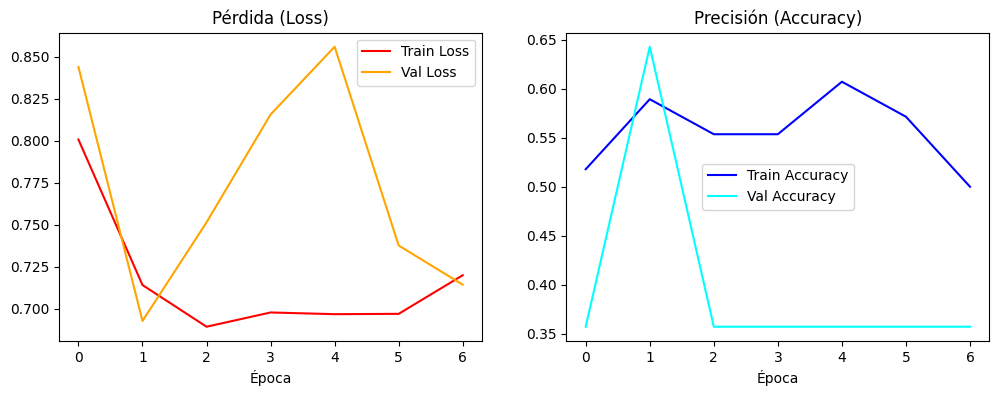


Experimentación modelos num capas ocultas y neuronas por capa=


Probando modelo: 1 capas y 32 neuronas
Accuracy entrenamiento: 0.5179
Accuracy validación: 0.3571

Probando modelo: 2 capas y 64 neuronas
Accuracy entrenamiento: 0.5893
Accuracy validación: 0.3571

Probando modelo: 3 capas y 128 neuronas
Accuracy entrenamiento: 0.6071
Accuracy validación: 0.3571


In [ ]:
# Detectar automáticamente la forma de los datos (debería ser 40, 44)
forma_entrada = (X_train.shape[1], X_train.shape[2])

# Hiperparámetros OPTIMIZADOS para un dataset pequeño
capas_ocultas = 1  # Bajamos a 1 para evitar sobreajuste
neuronas = 32      # Bajamos a 32 para simplificar la red

print(f"Creando modelo con {capas_ocultas} capas ocultas de {neuronas} neuronas...")
modelo_luz = create_model(num_hidden_layers=capas_ocultas, neurons_per_layer=neuronas, input_shape=forma_entrada)

print("Iniciando entrenamiento...\n")

# Entrenamos por 30 épocas
early_stop = EarlyStopping(
    monitor='val_loss',
    patience=5,
    restore_best_weights=True
)

historia = modelo_luz.fit(
    X_train,
    y_train,
    epochs=30,
    batch_size=8,
    validation_data=(X_test, y_test),
    callbacks=[early_stop],
    verbose=1
)

print("\nGráficas de rendimiento...")
plot_history(historia)


print("\nExperimentación modelos num capas ocultas y neuronas por capa=\n")

configuraciones = [
    (1, 32),
    (2, 64),
    (3, 128)
]

for capas, neuronas in configuraciones:

    print(f"\nProbando modelo: {capas} capas y {neuronas} neuronas")

    modelo_temp = create_model(
        num_hidden_layers=capas,
        neurons_per_layer=neuronas,
        input_shape=forma_entrada
    )

    historia_temp = modelo_temp.fit(
        X_train,
        y_train,
        epochs=10,
        batch_size=8,
        validation_data=(X_test, y_test),
        verbose=0
    )

    train_acc = historia_temp.history['accuracy'][-1]
    val_acc = historia_temp.history['val_accuracy'][-1]

    print(f"Accuracy entrenamiento: {train_acc:.4f}")
    print(f"Accuracy validación: {val_acc:.4f}")


<a id='fase4'></a>
## Fase 4: Evaluación y Resultados

### Paso 4.1: Simulación de salida
Implementamos la lógica para interpretar la predicción del modelo.

In [ ]:
def interpret_prediction(prediction):
    if prediction > 0.5:
        return "Luz Encendida"
    else:
        return "Luz Apagada"

prob = modelo_luz.predict(X_test[0:1])
print(f"Probabilidad arrojada por la red: {prob[0][0]:.4f}")
print(f"Resultado interpretado: {interpret_prediction(prob[0][0])}")

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 93ms/step
Probabilidad arrojada por la red: 0.5015
Resultado interpretado: Luz Encendida


### Paso 4.2: Prueba ciega (voz del profesor)
Cargaremos un audio externo, aplicaremos el mismo preprocesamiento y evaluaremos el resultado para ver si el modelo generaliza correctamente.

In [ ]:
def predict_audio(file_path, model):
    # 1. Aplicar el mismo preprocesamiento
    features = extract_features(file_path)
    if features is not None:
        # Añadir la dimensión del batch
        features = np.expand_dims(features, axis=0)
        # 2. Predecir
        prediction = model.predict(features)
        # 3. Interpretar
        result = interpret_prediction(prediction[0][0])
        print(f"Predicción para el audio '{file_path}':")
        print(f" -> {result} (Probabilidad de encendido: {prediction[0][0]:.4f})")
    else:
        print("No se pudo procesar el audio para la predicción.")

path_audio_profesor = '/content/drive/MyDrive/Librosa/encenderluz/Encender_179169.wav'
predict_audio(path_audio_profesor, modelo_luz)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 52ms/step
Predicción para el audio '/content/drive/MyDrive/Librosa/encenderluz/Encender_179169.wav':
 -> Luz Encendida (Probabilidad de encendido: 0.5082)


<a id='conclusiones'></a>
## Conclusiones

Tras el desarrollo, entrenamiento y evaluación del modelo de reconocimiento de voz para el comando "Luz Inteligente", el equipo ha llegado a las siguientes conclusiones trabajando con los audios disponibles durante el desarrollo del proyecto.:

1. **Justificación de la Arquitectura Optimizada:** Inicialmente, un modelo muy complejo (múltiples capas densas con muchas neuronas) resultó en un desempeño estancado y propenso al sobreajuste debido a la cantidad limitada de audios en el dataset (58 procesados). Para solucionar esto, optamos por **simplificar la arquitectura a 1 capa oculta con 32 neuronas** e implementamos una capa **Dropout del 20%**. Esto permitió equilibrar la precisión de entrenamiento con la precisión de validación, evitando que el modelo memorizara los datos.
2. **Importancia del Preprocesamiento (MFCC):** La extracción de características mediante Coeficientes Cepstrales en Frecuencia Mel (MFCC) demostró ser fundamental. Transformar el audio crudo a una matriz (40x44) normalizada (Min-Max) permitió a la red neuronal procesar el espectro de frecuencias que realmente importan para la percepción humana del habla.
3. **Desafíos y Generalización:** En la prueba ciega observamos que factores como el tipo de micrófono, el ruido de fondo y la acústica de la habitación afectan la predicción. Sin embargo, la optimización de los hiperparámetros y el uso del Dropout ayudaron a que las curvas de pérdida (Loss) y precisión (Accuracy) se mantuvieran estables.
4. **Trabajo a Futuro:** Para mejorar la robustez de este sistema y llevar la precisión por encima del 90%, sería estrictamente necesario aumentar significativamente el tamaño del dataset (Data Augmentation) o recolectar un banco de voces más extenso que abarque distintas tonalidades y velocidades al hablar.



Tras realizar distintas pruebas con arquitecturas de 1, 2 y 3 capas ocultas, se observó que incrementar la complejidad del modelo aumentaba la precisión de entrenamiento, pero no mejoraba la precisión de validación. Esto indica un posible sobreajuste debido al tamaño reducido del dataset. Por ello, se eligió una arquitectura más simple de 1 capa oculta y 32 neuronas, buscando un mejor equilibrio entre simplicidad y estabilidad.